In [29]:
from google.colab import files
uploaded = files.upload()


Saving RatingsMovies.csv to RatingsMovies (2).csv


In [30]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [31]:

df = pd.read_csv("RatingsMovies.csv")

In [32]:
user_ids = df["user_id"].unique()
movie_ids = df["movie_id"].unique()

user_map = {u: i for i, u in enumerate(user_ids)}
movie_map = {m: i for i, m in enumerate(movie_ids)}

df["user_enc"] = df["user_id"].map(user_map).astype(int)
df["movie_enc"] = df["movie_id"].map(movie_map).astype(int)

print("Số user:", len(user_map))
print("Số movie:", len(movie_map))

Số user: 943
Số movie: 1682


In [33]:
np.random.seed(42)
idx = np.arange(len(df))
np.random.shuffle(idx)

cut = int(0.8 * len(df))
train_idx, test_idx = idx[:cut], idx[cut:]

train_df = df.iloc[train_idx].copy()
test_df  = df.iloc[test_idx].copy()


In [34]:
# 4) BASELINE MEAN + BIAS
# r_hat = mu + b_u + b_m
mu = train_df["rating"].mean()

num_users = len(user_map)
num_movies = len(movie_map)

bu = np.zeros(num_users)
bm = np.zeros(num_movies)

lam = 10.0
epochs = 10

for ep in range(epochs):
    for u in train_df["user_enc"].unique():
        rows = train_df[train_df["user_enc"] == u]
        r = rows["rating"].to_numpy(dtype=float)
        m = rows["movie_enc"].to_numpy(dtype=int)

        s = 0.0
        for ri, mi in zip(r, m):
            s += ri - mu - bm[mi]
        bu[u] = s / (lam + len(r))

    for m_id in train_df["movie_enc"].unique():
        rows = train_df[train_df["movie_enc"] == m_id]
        r = rows["rating"].to_numpy(dtype=float)
        u = rows["user_enc"].to_numpy(dtype=int)

        s = 0.0
        for ri, ui in zip(r, u):
            s += ri - mu - bu[ui]
        bm[m_id] = s / (lam + len(r))


    preds = []
    trues = train_df["rating"].to_numpy(dtype=float)
    for u, m in zip(train_df["user_enc"], train_df["movie_enc"]):
        preds.append(mu + bu[u] + bm[m])
    preds = np.array(preds)

    rmse_train = np.sqrt(np.mean((trues - preds) ** 2))
    print(f"Epoch {ep+1}/{epochs} - Train RMSE: {rmse_train:.4f}")

Epoch 1/10 - Train RMSE: 0.9354
Epoch 2/10 - Train RMSE: 0.9238
Epoch 3/10 - Train RMSE: 0.9228
Epoch 4/10 - Train RMSE: 0.9225
Epoch 5/10 - Train RMSE: 0.9223
Epoch 6/10 - Train RMSE: 0.9222
Epoch 7/10 - Train RMSE: 0.9221
Epoch 8/10 - Train RMSE: 0.9220
Epoch 9/10 - Train RMSE: 0.9219
Epoch 10/10 - Train RMSE: 0.9219


In [35]:
# 5) ĐÁNH GIÁ TRÊN TEST
y_test = test_df["rating"].to_numpy(dtype=float)
y_pred = np.array([
    mu + bu[u] + bm[m]
    for u, m in zip(test_df["user_enc"], test_df["movie_enc"])
])

errors = y_test - y_pred
rmse = np.sqrt(np.mean(errors ** 2))
mae  = np.mean(np.abs(errors))

print("\n===== BASELINE MEAN RESULT =====")
print("RMSE:", rmse)
print("MAE :", mae)


===== BASELINE MEAN RESULT =====
RMSE: 0.9432713095646919
MAE : 0.7477271628930204


In [36]:
# 6) EXPORT FILE ENCODE (DÙNG CHUNG CHO CÁC MODEL SAU)
encoded_df = df.copy()

encoded_df["user_bias"] = encoded_df["user_enc"].map(lambda x: bu[x])
encoded_df["movie_bias"] = encoded_df["movie_enc"].map(lambda x: bm[x])
encoded_df["global_mean"] = mu

encoded_df["baseline_pred"] = (
    encoded_df["global_mean"]
    + encoded_df["user_bias"]
    + encoded_df["movie_bias"]
)

encoded_df.to_csv("ratings_baseline_label_encoded.csv", index=False)
print(" Đã lưu ratings_baseline_label_encoded.csv")

 Đã lưu ratings_baseline_label_encoded.csv


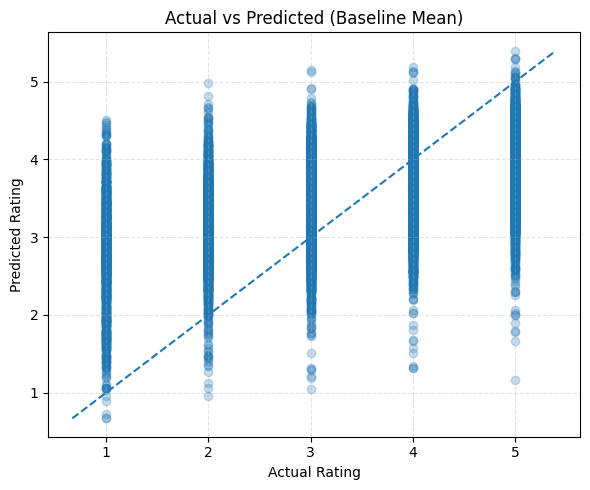

In [37]:
# 7) VISUALIZATION
plt.figure(figsize=(6,5))
plt.scatter(y_test, y_pred, alpha=0.25)
min_v = min(y_test.min(), y_pred.min())
max_v = max(y_test.max(), y_pred.max())
plt.plot([min_v, max_v], [min_v, max_v], linestyle="--")
plt.title("Actual vs Predicted (Baseline Mean)")
plt.xlabel("Actual Rating")
plt.ylabel("Predicted Rating")
plt.grid(True, linestyle="--", alpha=0.35)
plt.tight_layout()
plt.show()


In [38]:

# 8) SAVE MODEL RESULT (SUMMARY)
result_df = pd.DataFrame({
    "Model": ["Baseline Mean + User Bias + Movie Bias"],
    "RMSE": [rmse],
    "MAE": [mae],
    "GlobalMean": [mu],
    "Lambda": [lam],
    "Epochs": [epochs],
    "NumUsers": [num_users],
    "NumMovies": [num_movies]
})
result_df.to_csv("baseline_mean_result.csv", index=False)
print("Đã lưu baseline_mean_result.csv")

Đã lưu baseline_mean_result.csv
